# Comparative analysis: Russell vs Hamilton – Q3 Barcelona 2026

Objective: to identify where each driver gains time on their fastest lap, by overlaying telemetry data and a colour-coded circuit map.

**Author**: Marie Bouteyre
**Data**: FastF1

## 1. Setup and data loading

In [15]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Barcelona', 'Q')
session.load()
circuit_info = session.get_circuit_info()

core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']


## 2. Extracting fast laps and telemetry data

In [16]:

rus_lap = session.laps.pick_drivers('RUS').pick_fastest()
ham_lap = session.laps.pick_drivers('HAM').pick_fastest()

tel1 = rus_lap.get_telemetry()
tel2 = ham_lap.get_telemetry()

print(f"Russell : {rus_lap['LapTime']}")
print(f"Hamilton  : {ham_lap['LapTime']}")
print(f"Delta   : {(ham_lap['LapTime'] - rus_lap['LapTime']).total_seconds():.3f} s")

Russell : 0 days 00:01:14.679000
Hamilton  : 0 days 00:01:14.743000
Delta   : 0.064 s


## 3. Normalisation of distances travelled and calculation of the time difference

In [17]:
# --- Calculation of the time delta ---
t1 = (tel1['Time'] - tel1['Time'].iloc[0]).dt.total_seconds().values
t2 = (tel2['Time'] - tel2['Time'].iloc[0]).dt.total_seconds().values
t1_max = tel1['Time'].dt.total_seconds().max()
d1 = tel1['Distance'].values
d2 = tel2['Distance'].values

# Standardise both distances to a common length
L = max(d1.max(), d2.max())
d1_norm = d1 * L / d1.max()
d2_norm = d2 * L / d2.max()

t2_interp = np.interp(d1_norm, d2_norm, t2)
delta_time = t1 - t2_interp
print(f"Final delta : {delta_time[-1]:.3f}")

Final delta : -0.064


## 4. Speed and delta comparison

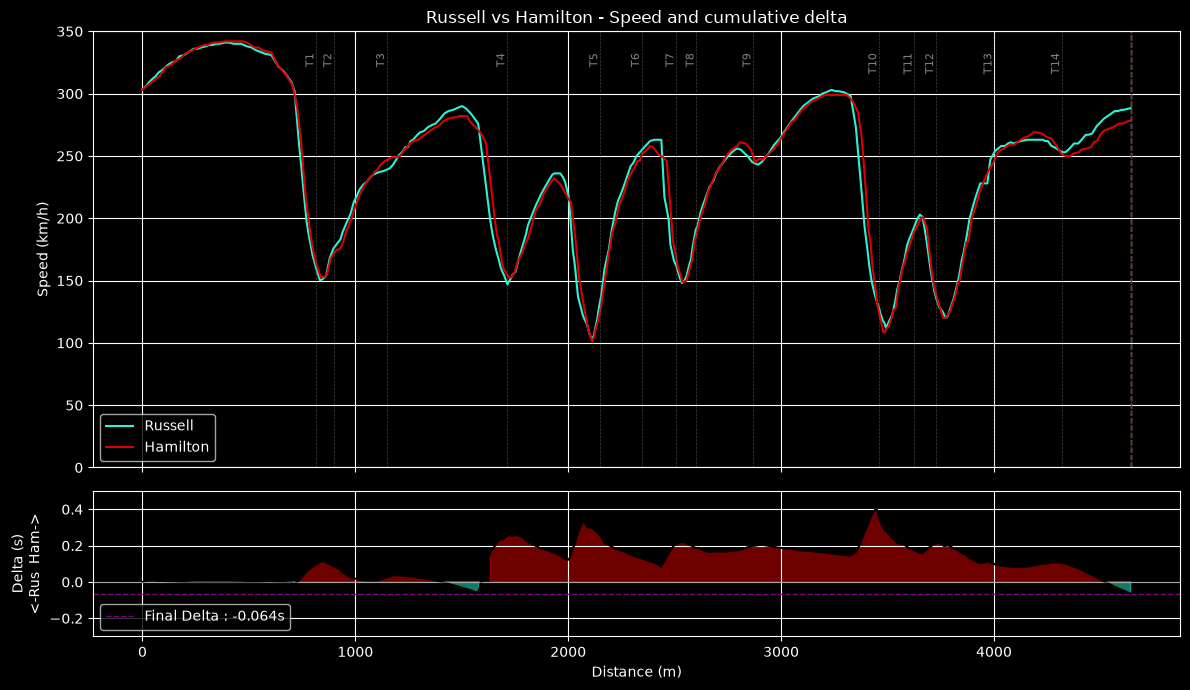

In [18]:
t1_max = t1.max()
t2_interp_max = t2.max()
delta_time_max = t1_max - t2_interp_max 
plt.style.use('dark_background')

# --- Graph 1: speed + delta ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(d1_norm, tel1['Speed'], label='Russell', color='#27F4D2')
ax1.plot(d2_norm, tel2['Speed'], label='Hamilton', color='#DC0000')
ax1.set_ylabel('Speed (km/h)')
ax1.set_title('Russell vs Hamilton - Speed and cumulative delta')

ax1.set_ylim(0, 350)
ax1.legend()
ax1.grid()

ax2.plot(d1_norm, delta_time, color='black', linewidth=1.5)
ax2.fill_between(d1_norm, delta_time, 0, where=(delta_time < 0), color='#27F4D2', alpha=0.5)
ax2.fill_between(d1_norm, delta_time, 0, where=(delta_time >= 0), color='#DC0000', alpha=0.5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Delta (s)\n<-Rus  Ham->')
ax2.grid()
ax2.set_ylim(-0.3, 0.5)

#  Adds a vertical line and the number at each corner
for _, corner in circuit_info.corners.iterrows():
    txt = f"T{corner['Number']}{corner['Letter']}"
    ax1.axvline(x=corner['Distance'], color='gray', 
                linestyle='--', linewidth=0.5, alpha=0.5)
    ax1.text(corner['Distance'], ax1.get_ylim()[1] * 0.95, 
             txt, rotation=90, va='top', ha='right', 
             fontsize=8, color='gray')

rus_dis_norm_tot = d1_norm.max()
ham_dis_norm_tot = d2_norm.max()

ax1.axvline(x=rus_dis_norm_tot, color='#27F4D2', linestyle='--', linewidth=1, alpha=1)
ax1.axvline(x=ham_dis_norm_tot, color='#DC0000', linestyle='--', linewidth=1, alpha=1)
ax2.axhline(y=delta_time_max, color='purple', linestyle='--', 
            linewidth=1, label=f'Final Delta : {delta_time[-1]:.3f}s')
ax2.legend(loc='lower left')


plt.tight_layout()
plt.show()


## 5. Colour-coded map of the circuit

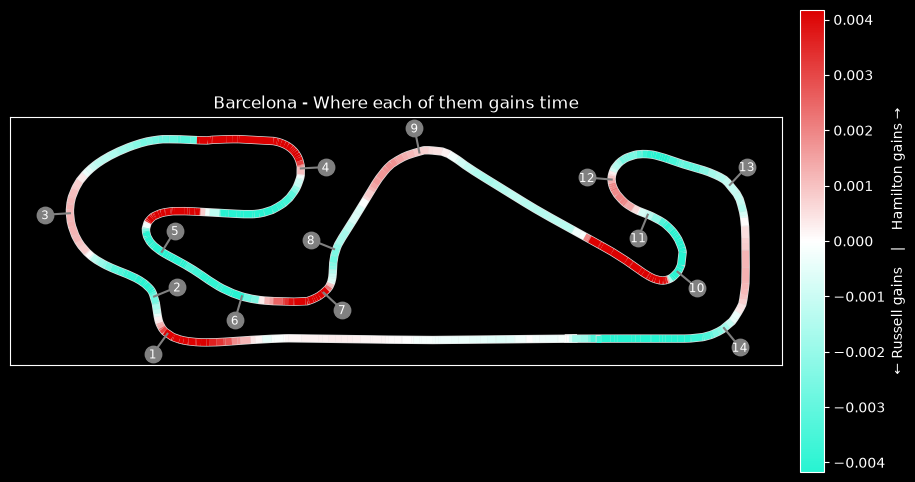

In [19]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d
import numpy as np
import matplotlib.pyplot as plt


def rotate(xy, *, angle):
    rot_mat = np.array([[np.cos(angle), np.sin(angle)],
                        [-np.sin(angle), np.cos(angle)]])
    return np.matmul(xy, rot_mat)


# --- Retrieving positions ---
x = tel1['X'].values
y = tel1['Y'].values

# Rotation to ensure the circuit is correctly oriented
track_angle = circuit_info.rotation / 180 * np.pi
xy = np.array([x, y]).T
xy_rot = rotate(xy, angle=track_angle)
x_rot, y_rot = xy_rot[:, 0], xy_rot[:, 1]

# --- Construction of segments ---
points = np.array([x_rot, y_rot]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# --- Calculation of the local gain (smoothed delta, then derivative) ---
delta_smooth = uniform_filter1d(delta_time, size=20)
delta_diff = np.diff(delta_smooth)

# --- Colormap and normalisation ---
cmap = LinearSegmentedColormap.from_list(
    'rus_ham', ['#27F4D2', '#FFFFFF', '#DC0000']
)
vmax = np.percentile(np.abs(delta_diff), 70)
norm = plt.Normalize(vmin=-vmax, vmax=vmax)

# --- Circuit ---
fig, ax = plt.subplots(figsize=(12, 12))

# Circuit layout (below)
ax.plot(x_rot, y_rot, color='black', linewidth=8, zorder=1)
ax.plot(x_rot, y_rot, color='#e0e0e0', linewidth=6, zorder=2)

# Colourful LineCollection on top
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=5, zorder=3)
lc.set_array(delta_diff)
ax.add_collection(lc)

# Colour bar
cbar = plt.colorbar(lc, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('← Russell gains    |    Hamilton gains →')

# --- Corners numbering ---
offset_vector = [500, 0]
for _, corner in circuit_info.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    offset_angle = corner['Angle'] / 180 * np.pi
    offset_x, offset_y = rotate(offset_vector, angle=offset_angle)
    text_x = corner['X'] + offset_x
    text_y = corner['Y'] + offset_y
    text_x, text_y = rotate([text_x, text_y], angle=track_angle)
    track_x, track_y = rotate([corner['X'], corner['Y']], angle=track_angle)
    ax.scatter(text_x, text_y, color='grey', s=140, zorder=4)
    ax.plot([track_x, text_x], [track_y, text_y], color='grey', zorder=3)
    ax.text(text_x, text_y, txt, va='center_baseline', ha='center',
            size='small', color='white', zorder=5)

# --- Formatting ---
ax.set_title(f"{session.event['Location']} - Where each of them gains time")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
ax.autoscale()
plt.show()

## 6. Breakdown of a gap of -0.064s

During Q3 at the Barcelona GP in 2026, George Russell (Mercedes) set the fastest qualifying lap, beating Lewis Hamilton (Ferrari) by just 0.064s. At first glance, this pole position might appear to be a straightforward win for Russell, but on closer inspection, a counter-intuitive situation emerges: Hamilton actually led for almost the entire lap. Everything changed in the final sector.

Right up until the approach to T4, no significant lead is apparent on the delta graph. Braking later allowed Hamilton to pull ahead of his rival with a delta of just over 0.2s as they approached the middle sector (T4–T9). This lead fluctuated, due to the trade-off between corner entry and exit, but remained at 0.2s in Hamilton’s favour as he exited T9.

Next came the 350–400 metre straight between T9 and T10. Hamilton then passed the apex of T10 at a speed approximately 5 km/h slower than Russell’s. Consequently, he was unable to re-establish a significant gap through the T10–T11–T12 sequence, allowing Russell to gradually close the gap. Thus, on exiting T12 and approaching T13, Hamilton’s lead was reduced to just 0.1s.

Russell eventually overtook Hamilton on the home straight, following an earlier and stronger acceleration out of T14. On the speed trace, his acceleration curve at this stage is significantly steeper than Hamilton's. He crossed the line at a speed approximately 10 km/h higher than his rival’s.

In the context of the 2026 regulations, electric energy management has become a critical issue, particularly in high-acceleration sectors. Karun Chandhok’s SkyPad analysis, published after qualifying, attributes Hamilton’s loss to a lack of electrical energy deployment at the end of the lap. This analysis is consistent with the observations presented here. It remains, however, impossible to draw a definitive conclusion without access to direct ERS data.

In conclusion, this 0.064s gap in Russell’s favour does not reflect the reality of lap performance. In terms of pure driver performance, Hamilton set the fastest lap. It was the final metres, likely determined by energy management, that secured pole position. This illustrates, in particular, how the 2026 regulations are shifting the focus of driving from pure driving skill towards the ERS management.
